# Porównanie algorytmów: Genetyczny vs Pszczeli

Eksperymenty porównawcze z użyciem wspólnej populacji początkowej.

In [2]:
import time
import random
from dataclasses import dataclass, field
from abc import ABC, abstractmethod

import matplotlib.pyplot as plt

from problem_solution import Problem, Solution
from genetic_new_hope import GeneticSolver
from bee_solver import BeeSolver

<frozen importlib._bootstrap>:491: Warning: Numpy built with MINGW-W64 on Windows 64 bits is experimental, and only available for 
testing. You are advised not to use it for production. 

CRASHES ARE TO BE EXPECTED - PLEASE REPORT THEM TO NUMPY DEVELOPERS
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\numpy\_core\getlimits.py:229: RuntimeWarning: invalid value encountered in exp2
  epsneg_f128 = exp2(ld(-113))
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\numpy\_core\getlimits.py:230: RuntimeWarning: invalid value encountered in exp2
  tiny_f128 = exp2(ld(-16382))
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\numpy\_core\getlimits.py:244: RuntimeWarning: invalid value encountered in exp2
  eps=exp2(ld(-112)),
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\numpy\_core\getlimits.py:41: RuntimeWarning: invalid value encountered in nextafter
  self._smallest_subnormal = nextafter(
C:\Users\Admin\AppData\Roaming\Python\Python314\

## Klasy niezbędne do przeprowadzenia eksperymentów

In [3]:
def generate_initial_population(problem: Problem, population_size: int) -> list[list[int]]:
    keys = list(problem.situations.keys())
    population = []
    for _ in range(population_size):
        order = list(keys)
        random.shuffle(order)
        population.append(order)
    return population

In [4]:
@dataclass
class ExperimentResult:
    """Wynik pojedynczego uruchomienia algorytmu."""
    algorithm_name: str
    final_cost: float
    elapsed_time: float
    is_correct: bool
    best_costs: list[float]
    avg_costs: list[float]
    solution: Solution

    def summary(self) -> str:
        return (
            f"{self.algorithm_name}:\n"
            f"  Czas:      {self.elapsed_time:.3f} s\n"
            f"  Koszt:     {self.final_cost}\n"
            f"  Poprawny:  {self.is_correct}"
        )
    
    @staticmethod
    def combine(results: list["ExperimentResult"]) -> "ExperimentResult":
        algorithm_name = results[0].algorithm_name
        final_cost = min(result.final_cost for result in results)
        elapsed_time = sum(result.elapsed_time for result in results)
        is_correct = all(result.is_correct for result in results)
        best_costs = [min(results[j].best_costs[i] for j in range(len(results))) for i in range(len(results[0].best_costs))]
        avg_costs = [sum(results[j].avg_costs[i] for j in range(len(results)))/len(results) for i in range(len(results[0].avg_costs))]
        solution = results[0].solution
        return ExperimentResult(algorithm_name, final_cost, elapsed_time, is_correct, best_costs, avg_costs, solution)


In [5]:
class SolverAdapter(ABC):
    """Abstrakcja opakowująca dowolny solver w jednolity interfejs."""

    def __init__(self, name: str):
        self.name = name

    @abstractmethod
    def run(self, problem: Problem, generations: int, initial_population: list[list[int]]) -> ExperimentResult:
        ...


class GeneticAdapter(SolverAdapter):
    def __init__(self, name: str = "Genetic", mutation_rate: float = 0.25, mutate_mode: str = "swap", crossover_mode: str = "keep_splice"):
        super().__init__(name)
        self.mutation_rate = mutation_rate
        self.mutate_mode = mutate_mode
        self.crossover_mode = crossover_mode

    def run(self, problem: Problem, generations: int, initial_population: list[list[int]]) -> ExperimentResult:
        pop_size = len(initial_population)
        solver = GeneticSolver(
            problem,
            population_size=pop_size,
            mutation_rate=self.mutation_rate,
            mutate_mode=self.mutate_mode,
            crossover_mode=self.crossover_mode,
        )
        start = time.perf_counter()
        solution = solver.evolve(
            generations=generations,
            initial_population=initial_population,
            save_history=True,
            verbose=False,
        )
        solution.calculate_cost_function()
        elapsed = time.perf_counter() - start

        return ExperimentResult(
            algorithm_name=self.name,
            final_cost=solution.get_cost(),
            elapsed_time=elapsed,
            is_correct=solution.is_correct(),
            best_costs=[h[0] for h in solver.history],
            avg_costs=[h[1] for h in solver.history],
            solution=solution,
        )


class BeeAdapter(SolverAdapter):
    def __init__(self, name: str = "Bee", good_elite_cnt: int = 10, elite_cnt: int = 3, local_elite_cnt: int = 10, local_good_cnt: int = 4):
        super().__init__(name)
        self.good_elite_cnt = good_elite_cnt
        self.elite_cnt = elite_cnt
        self.local_elite_cnt = local_elite_cnt
        self.local_good_cnt = local_good_cnt

    def run(self, problem: Problem, generations: int, initial_population: list[list[int]]) -> ExperimentResult:
        pop_size = len(initial_population)
        solver = BeeSolver(
            problem,
            bees_cnt=pop_size,
            good_elite_cnt=self.good_elite_cnt,
            elite_cnt=self.elite_cnt,
            local_elite_cnt=self.local_elite_cnt,
            local_good_cnt=self.local_good_cnt,
        )
        start = time.perf_counter()
        solution = solver.evolve(
            iterations=generations,
            initial_population=initial_population,
            verbose=False,
        )
        elapsed = time.perf_counter() - start

        return ExperimentResult(
            algorithm_name=self.name,
            final_cost=solution.get_cost(),
            elapsed_time=elapsed,
            is_correct=solution.is_correct(),
            best_costs=[h[0] for h in solver.history],
            avg_costs=[h[1] for h in solver.history],
            solution=solution,
        )

In [6]:
@dataclass
class ExperimentConfig:
    """Konfiguracja pojedynczego eksperymentu."""
    name: str
    num_vertices: int = 60
    num_edges: int = 400
    min_weight: int = 1
    max_weight: int = 10
    num_situations: int = 20
    min_car_amount: int = 2
    max_car_amount: int = 5
    seed: int = 42
    generations: int = 40
    population_size: int = 50
    adapters: list[SolverAdapter] = field(default_factory=list)
    no_simulations: int = 10

    def build_problem(self) -> Problem:
        return Problem.random(
            num_vertices=self.num_vertices,
            num_edges=self.num_edges,
            min_weight=self.min_weight,
            max_weight=self.max_weight,
            num_situations=self.num_situations,
            min_car_amount=self.min_car_amount,
            max_car_amount=self.max_car_amount,
            seed=self.seed,
        )

In [7]:
class Experiment:
    """Uruchamia adaptery na wspólnej populacji i zbiera wyniki."""

    def __init__(self, config: ExperimentConfig):
        self.config = config
        self.problem = config.build_problem()
        assert self.problem.check_validity(), "Problem jest niepoprawny!"
        self.initial_population = generate_initial_population(self.problem, config.population_size)
        self.results: list[ExperimentResult] = []

    def run(self) -> list[ExperimentResult]:
        print(f"=== {self.config.name} ===")
        print(f"Populacja początkowa: {self.config.population_size} osobników")
        print(f"Generacje: {self.config.generations}\n")
        self.results = []
        for adapter in self.config.adapters:
            print(f"Uruchamiam: {adapter.name}...")
            results = []
            for _ in range(self.config.no_simulations):
                results.append(adapter.run(self.problem, self.config.generations, self.initial_population))
            result = ExperimentResult.combine(results)
            self.results.append(result)
            print(result.summary())
            print()
        return self.results

    def plot_best_costs(self, figsize=(10, 6)):
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
        markers = ['o', 's', '^', 'D', 'v', 'P', 'X']

        fig, ax = plt.subplots(figsize=figsize)
        for i, r in enumerate(self.results):
            ax.plot(
                r.best_costs,
                label=f"{r.algorithm_name} (koszt: {r.final_cost})",
                color=colors[i % len(colors)],
                marker=markers[i % len(markers)],
                markersize=4,
            )
        ax.set_title(f"{self.config.name} - najmniejszy koszt", fontsize=14)
        ax.set_xlabel("Generacja", fontsize=12)
        ax.set_ylabel("Koszt (najlepszy)", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(fontsize=11)
        ax.set_xticks(range(0, self.config.generations + 2, max(1, self.config.generations // 10)))
        fig.tight_layout()
        plt.show()

    def plot_avg_costs(self, figsize=(10, 6)):
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
        markers = ['o', 's', '^', 'D', 'v', 'P', 'X']

        fig, ax = plt.subplots(figsize=figsize)
        for i, r in enumerate(self.results):
            ax.plot(
                r.avg_costs,
                label=f"{r.algorithm_name} (avg final: {r.avg_costs[-1]:.0f})",
                color=colors[i % len(colors)],
                marker=markers[i % len(markers)],
                markersize=4,
                linestyle='--',
            )
        ax.set_title(f"{self.config.name} - średni koszt", fontsize=14)
        ax.set_xlabel("Generacja", fontsize=12)
        ax.set_ylabel("Koszt (średni)", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(fontsize=11)
        ax.set_xticks(range(0, self.config.generations + 2, max(1, self.config.generations // 10)))
        fig.tight_layout()
        plt.show()

    def summary_table(self):
        print(f"\n{'Algorytm':<30} | {'Czas [s]':>10} | {'Koszt':>10} | {'Poprawny':>10}")
        print("-" * 70)
        for r in self.results:
            print(f"{r.algorithm_name:<30} | {r.elapsed_time:>10.3f} | {r.final_cost:>10} | {str(r.is_correct):>10}")

=== Tytuł eksperymentu ===
Populacja początkowa: 50 osobników
Generacje: 15

Uruchamiam: Eksperyment 1...
Eksperyment 1:
  Czas:      7.536 s
  Koszt:     2474
  Poprawny:  True

Uruchamiam: Eksperyment 2...
Eksperyment 2:
  Czas:      13.141 s
  Koszt:     2502
  Poprawny:  True



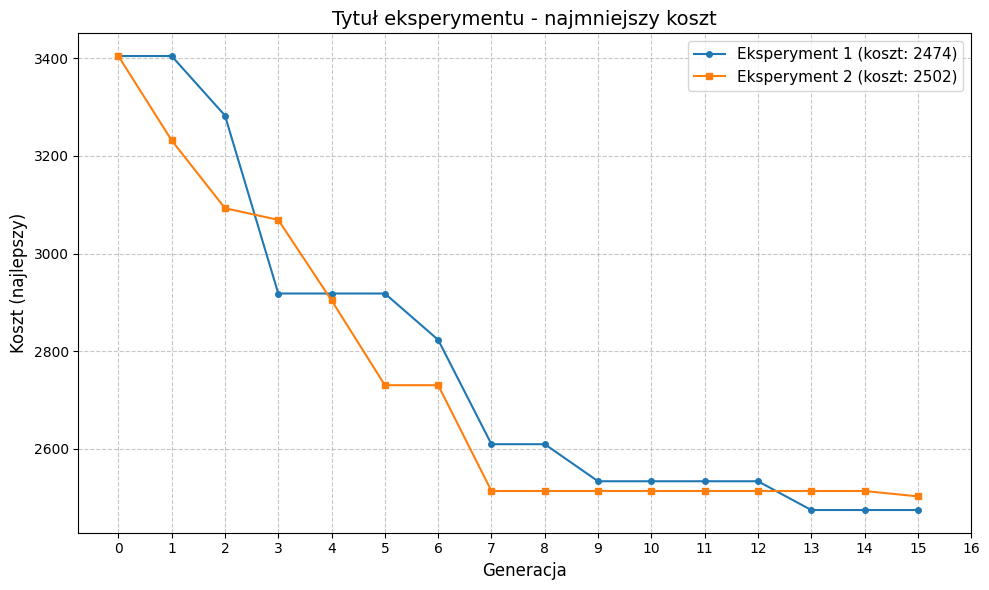

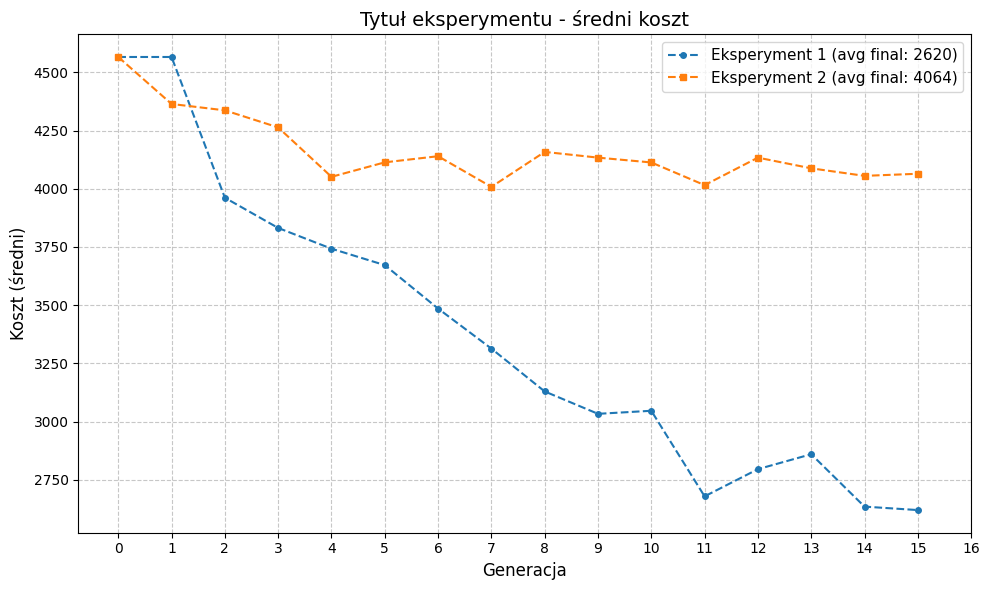


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
Eksperyment 1                  |      7.536 |       2474 |       True
Eksperyment 2                  |     13.141 |       2502 |       True


In [15]:
exp_name = Experiment(ExperimentConfig(
name="Tytuł eksperymentu",
seed=42,
generations=15,
population_size=50,
no_simulations=1, # ile razy należy powtórzyć eksperyment
adapters=[
    GeneticAdapter(name="Eksperyment 1", mutation_rate=0.25, mutate_mode="swap", 
                    crossover_mode="keep_splice"),
    BeeAdapter(name="Eksperyment 2", good_elite_cnt=10, elite_cnt=7, 
                local_elite_cnt=5, local_good_cnt=5),
    ]
))

exp_name.run()
exp_name.plot_best_costs()
exp_name.plot_avg_costs()
exp_name.summary_table()

# Eksperymenty algorytmu genetycznego

## Wpływ `mutation_mode`

=== Wpływ parametru mutate_mode ===
Populacja początkowa: 50 osobników
Generacje: 15

Uruchamiam: swap (mr=0.25)...
swap (mr=0.25):
  Czas:      71.924 s
  Koszt:     2215
  Poprawny:  True

Uruchamiam: swap (mr=0.60)...
swap (mr=0.60):
  Czas:      71.754 s
  Koszt:     2117
  Poprawny:  True

Uruchamiam: swap (mr=1.00)...
swap (mr=1.00):
  Czas:      71.593 s
  Koszt:     2164
  Poprawny:  True

Uruchamiam: reinsert (mr=0.25)...
reinsert (mr=0.25):
  Czas:      71.444 s
  Koszt:     2310
  Poprawny:  True

Uruchamiam: reinsert (mr=0.60)...
reinsert (mr=0.60):
  Czas:      72.261 s
  Koszt:     2159
  Poprawny:  True

Uruchamiam: reinsert (mr=1.00)...
reinsert (mr=1.00):
  Czas:      71.532 s
  Koszt:     2200
  Poprawny:  True



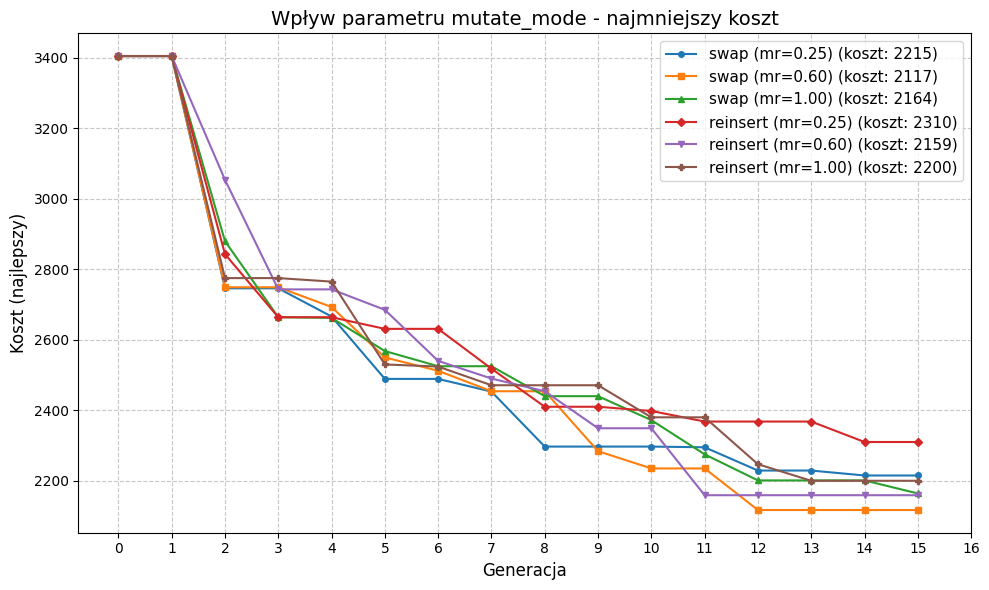

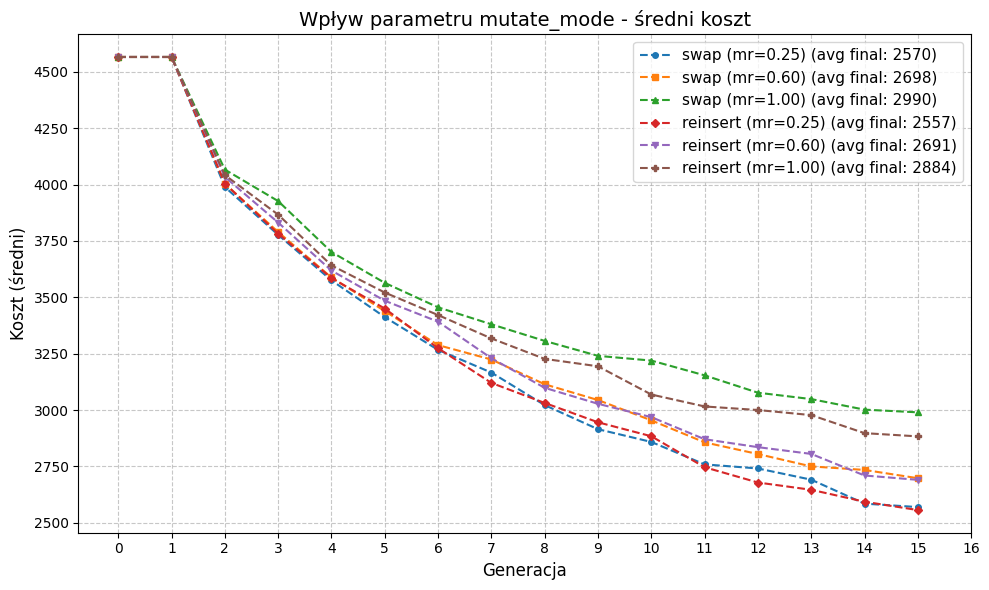


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
swap (mr=0.25)                 |     71.924 |       2215 |       True
swap (mr=0.60)                 |     71.754 |       2117 |       True
swap (mr=1.00)                 |     71.593 |       2164 |       True
reinsert (mr=0.25)             |     71.444 |       2310 |       True
reinsert (mr=0.60)             |     72.261 |       2159 |       True
reinsert (mr=1.00)             |     71.532 |       2200 |       True


In [8]:
mutation_mode_exp = Experiment(ExperimentConfig(
    name="Wpływ parametru mutate_mode",
    seed=42,
    generations=15,
    population_size=50,
    no_simulations=10,
    adapters=[
        GeneticAdapter(name="swap (mr=0.25)",   mutation_rate=0.25, mutate_mode="swap"),
        GeneticAdapter(name="swap (mr=0.60)",   mutation_rate=0.6, mutate_mode="swap"),
        GeneticAdapter(name="swap (mr=1.00)",   mutation_rate=1, mutate_mode="swap"),

        GeneticAdapter(name="reinsert (mr=0.25)",   mutation_rate=0.25, mutate_mode="reinsert"),
        GeneticAdapter(name="reinsert (mr=0.60)",   mutation_rate=0.6, mutate_mode="reinsert"),
        GeneticAdapter(name="reinsert (mr=1.00)",   mutation_rate=1, mutate_mode="reinsert"),
    ]
))

mutation_mode_exp.run()
mutation_mode_exp.plot_best_costs()
mutation_mode_exp.plot_avg_costs()
mutation_mode_exp.summary_table()

## Wpływ `mutation_rate`

=== Wpływ parametru mutate_rate ===
Populacja początkowa: 50 osobników
Generacje: 15

Uruchamiam: mr=0.20 (swap)...
mr=0.20 (swap):
  Czas:      72.723 s
  Koszt:     2187
  Poprawny:  True

Uruchamiam: mr=0.40 (swap)...
mr=0.40 (swap):
  Czas:      71.274 s
  Koszt:     2215
  Poprawny:  True

Uruchamiam: mr=0.60 (swap)...
mr=0.60 (swap):
  Czas:      70.961 s
  Koszt:     2171
  Poprawny:  True

Uruchamiam: mr=0.80 (swap)...
mr=0.80 (swap):
  Czas:      70.187 s
  Koszt:     2282
  Poprawny:  True

Uruchamiam: mr=1.00 (swap)...
mr=1.00 (swap):
  Czas:      75.713 s
  Koszt:     2221
  Poprawny:  True

Uruchamiam: mr=0.20 (reinsert)...
mr=0.20 (reinsert):
  Czas:      75.459 s
  Koszt:     2186
  Poprawny:  True

Uruchamiam: mr=0.40 (reinsert)...
mr=0.40 (reinsert):
  Czas:      75.445 s
  Koszt:     2210
  Poprawny:  True

Uruchamiam: mr=0.60 (reinsert)...
mr=0.60 (reinsert):
  Czas:      70.487 s
  Koszt:     2179
  Poprawny:  True

Uruchamiam: mr=0.80 (reinsert)...
mr=0.80 (reinser

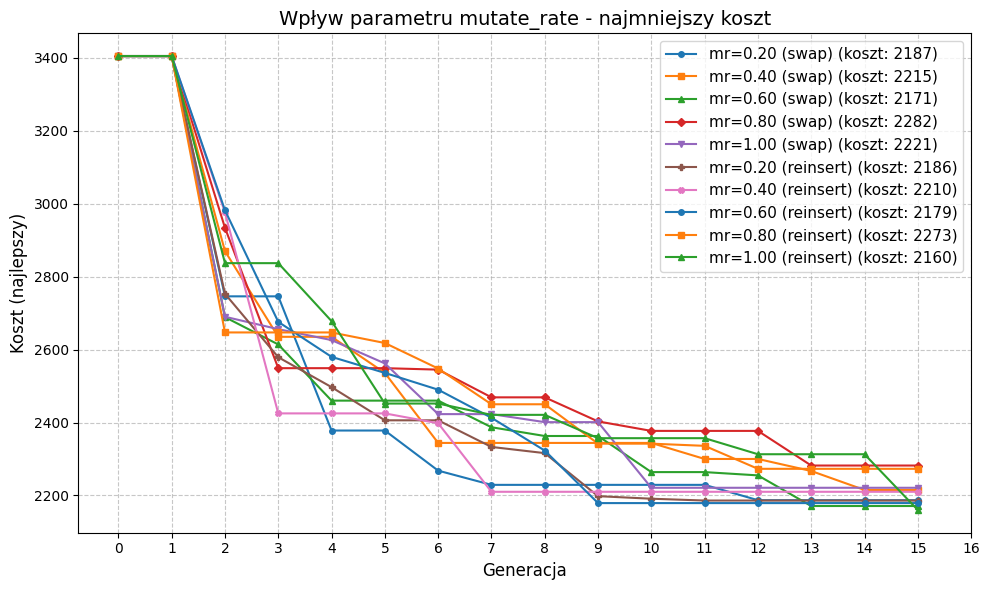

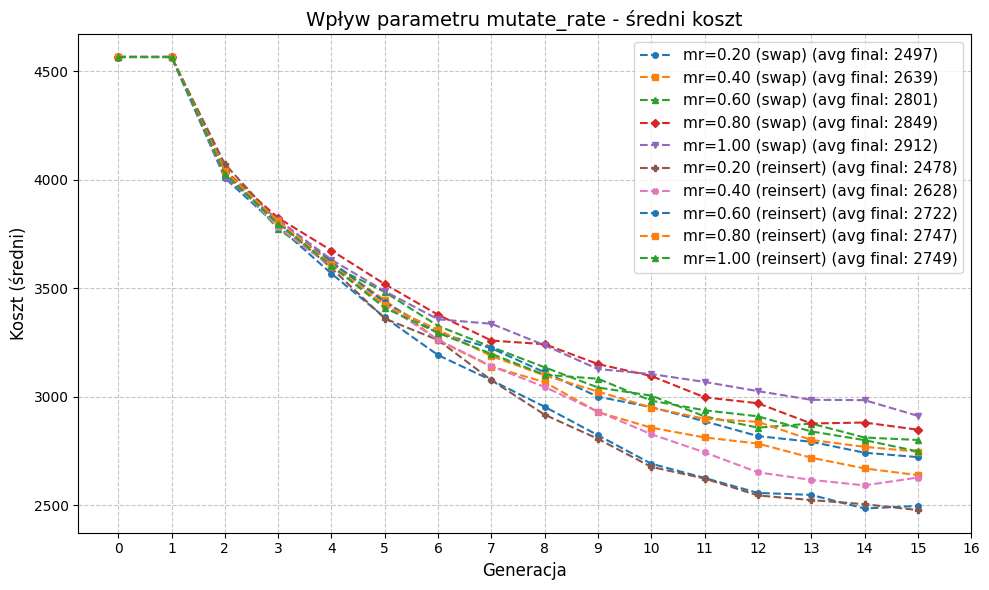


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
mr=0.20 (swap)                 |     72.723 |       2187 |       True
mr=0.40 (swap)                 |     71.274 |       2215 |       True
mr=0.60 (swap)                 |     70.961 |       2171 |       True
mr=0.80 (swap)                 |     70.187 |       2282 |       True
mr=1.00 (swap)                 |     75.713 |       2221 |       True
mr=0.20 (reinsert)             |     75.459 |       2186 |       True
mr=0.40 (reinsert)             |     75.445 |       2210 |       True
mr=0.60 (reinsert)             |     70.487 |       2179 |       True
mr=0.80 (reinsert)             |     71.231 |       2273 |       True
mr=1.00 (reinsert)             |     73.269 |       2160 |       True


In [11]:
mutation_rate_exp = Experiment(ExperimentConfig(
    name="Wpływ parametru mutate_rate",
    seed=42,
    generations=15,
    population_size=50,
    no_simulations=10,
    adapters=[
        GeneticAdapter(name="mr=0.20 (swap)",   mutation_rate=0.2, mutate_mode="swap"),
        GeneticAdapter(name="mr=0.40 (swap)",   mutation_rate=0.4, mutate_mode="swap"),
        GeneticAdapter(name="mr=0.60 (swap)",   mutation_rate=0.6, mutate_mode="swap"),
        GeneticAdapter(name="mr=0.80 (swap)",   mutation_rate=0.8, mutate_mode="swap"),
        GeneticAdapter(name="mr=1.00 (swap)",   mutation_rate=1, mutate_mode="swap"),

        GeneticAdapter(name="mr=0.20 (reinsert)",   mutation_rate=0.2, mutate_mode="reinsert"),
        GeneticAdapter(name="mr=0.40 (reinsert)",   mutation_rate=0.4, mutate_mode="reinsert"),
        GeneticAdapter(name="mr=0.60 (reinsert)",   mutation_rate=0.6, mutate_mode="reinsert"),
        GeneticAdapter(name="mr=0.80 (reinsert)",   mutation_rate=0.8, mutate_mode="reinsert"),
        GeneticAdapter(name="mr=1.00 (reinsert)",   mutation_rate=1, mutate_mode="reinsert"),
    ],
))

mutation_rate_exp.run()
mutation_rate_exp.plot_best_costs()
mutation_rate_exp.plot_avg_costs()
mutation_rate_exp.summary_table()

## Wpływ `crossover_mode`

=== Wpływ parametru crossover_mode ===
Populacja początkowa: 50 osobników
Generacje: 40

Uruchamiam: keep_splice (mr=0.25)...
keep_splice (mr=0.25):
  Czas:      180.174 s
  Koszt:     2058
  Poprawny:  True

Uruchamiam: keep_splice (mr=0.60)...
keep_splice (mr=0.60):
  Czas:      177.951 s
  Koszt:     2095
  Poprawny:  True

Uruchamiam: keep_splice (mr=1.00)...
keep_splice (mr=1.00):
  Czas:      180.819 s
  Koszt:     2058
  Poprawny:  True

Uruchamiam: swap_order (mr=0.25)...
swap_order (mr=0.25):
  Czas:      178.945 s
  Koszt:     2249
  Poprawny:  True

Uruchamiam: swap_order (mr=0.6)...
swap_order (mr=0.6):
  Czas:      182.390 s
  Koszt:     2107
  Poprawny:  True

Uruchamiam: swap_order (mr=1.00)...
swap_order (mr=1.00):
  Czas:      186.760 s
  Koszt:     2227
  Poprawny:  True



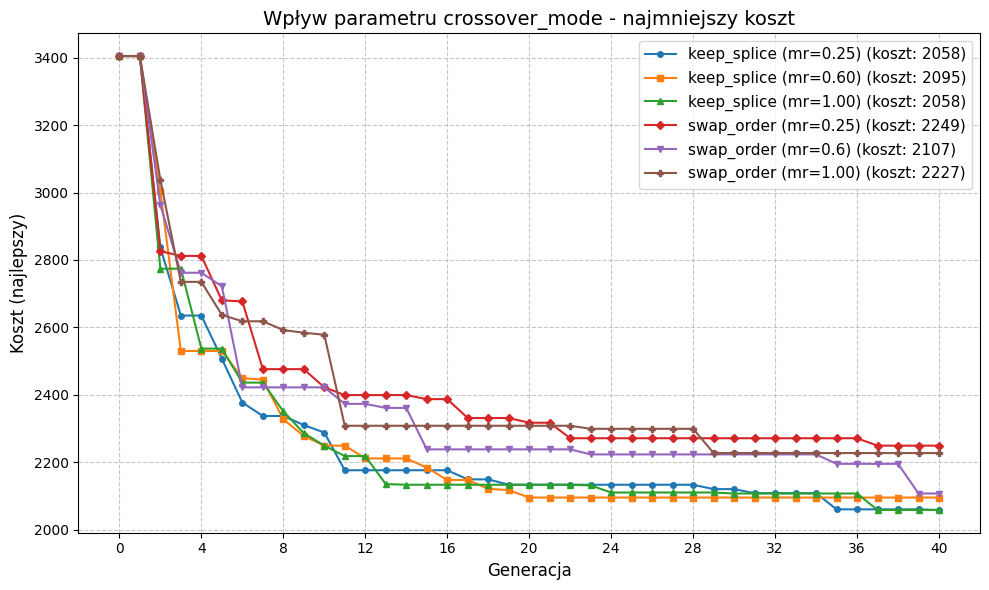

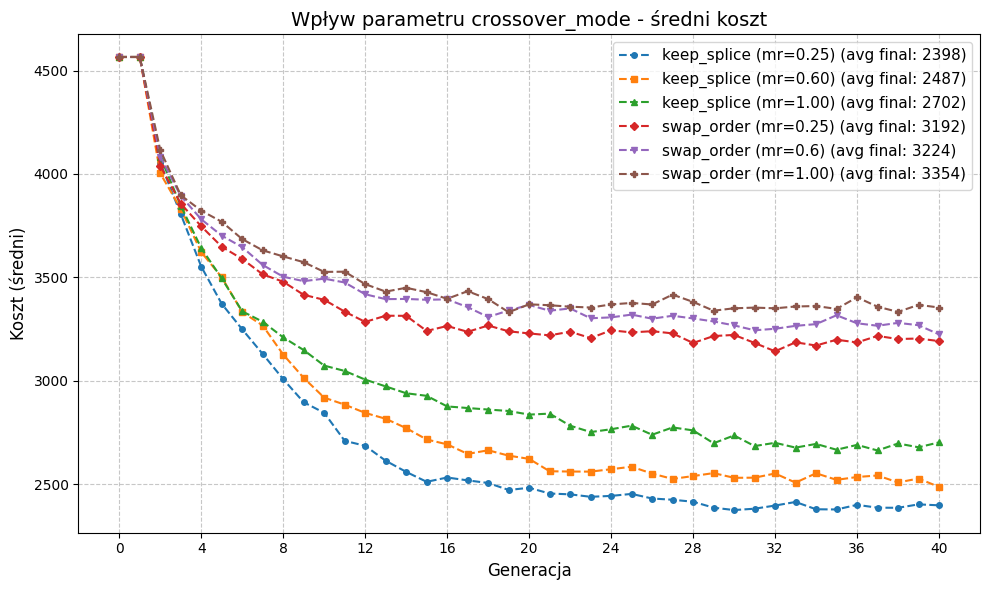


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
keep_splice (mr=0.25)          |    180.174 |       2058 |       True
keep_splice (mr=0.60)          |    177.951 |       2095 |       True
keep_splice (mr=1.00)          |    180.819 |       2058 |       True
swap_order (mr=0.25)           |    178.945 |       2249 |       True
swap_order (mr=0.6)            |    182.390 |       2107 |       True
swap_order (mr=1.00)           |    186.760 |       2227 |       True


In [12]:
crossover_mode_exp = Experiment(ExperimentConfig(
    name="Wpływ parametru crossover_mode",
    seed=42,
    generations=40,
    population_size=50,
    no_simulations=10,
    adapters=[
        GeneticAdapter(name="keep_splice (mr=0.25)", mutation_rate=0.25, crossover_mode="keep_splice"),
        GeneticAdapter(name="keep_splice (mr=0.60)", mutation_rate=0.6, crossover_mode="keep_splice"),
        GeneticAdapter(name="keep_splice (mr=1.00)", mutation_rate=1, crossover_mode="keep_splice"),
        
        GeneticAdapter(name="swap_order (mr=0.25)",  mutation_rate=0.25, crossover_mode="swap_order"),
        GeneticAdapter(name="swap_order (mr=0.6)",  mutation_rate=0.6, crossover_mode="swap_order"),
        GeneticAdapter(name="swap_order (mr=1.00)",  mutation_rate=1, crossover_mode="swap_order"),
    ],
))


crossover_mode_exp.run()
crossover_mode_exp.plot_best_costs()
crossover_mode_exp.plot_avg_costs()
crossover_mode_exp.summary_table()

# Eksperymenty algorytmu pszczelego

## Wpływ `good_elite_cnt`
Parametr ten jest odwrotnie proporcjonalny do liczby pszczół odpowiadających za losowe przeszukiwanie

=== Wpływ parametru good_elite_cnt ===
Populacja początkowa: 50 osobników
Generacje: 15

Uruchamiam: good_elite_cnt=10...
good_elite_cnt=10:
  Czas:      125.855 s
  Koszt:     2317
  Poprawny:  True

Uruchamiam: good_elite_cnt=20...
good_elite_cnt=20:
  Czas:      175.506 s
  Koszt:     2275
  Poprawny:  True

Uruchamiam: good_elite_cnt=30...
good_elite_cnt=30:
  Czas:      228.127 s
  Koszt:     2233
  Poprawny:  True

Uruchamiam: good_elite_cnt=40...
good_elite_cnt=40:
  Czas:      275.567 s
  Koszt:     2226
  Poprawny:  True



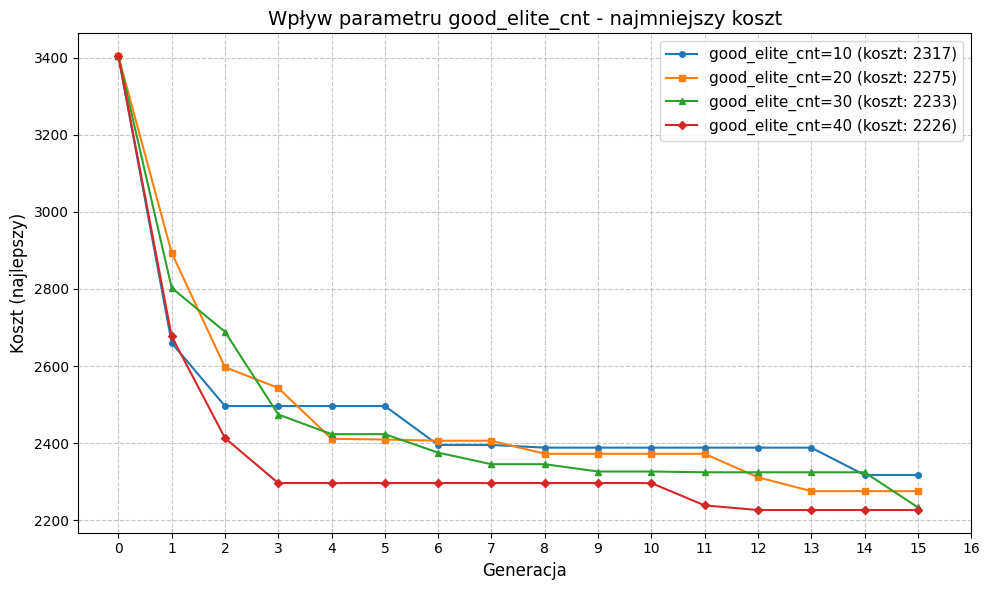

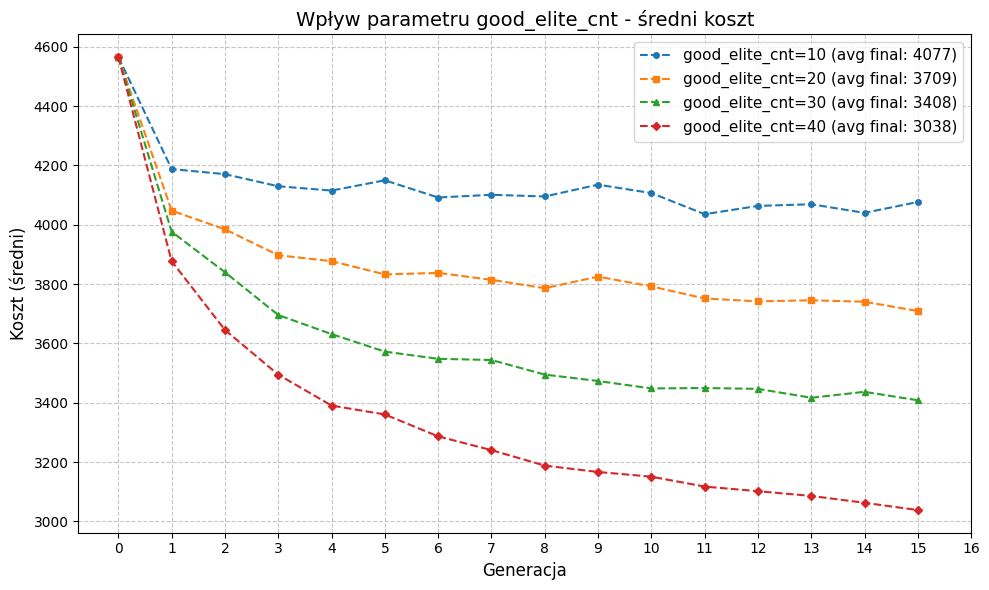


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
good_elite_cnt=10              |    125.855 |       2317 |       True
good_elite_cnt=20              |    175.506 |       2275 |       True
good_elite_cnt=30              |    228.127 |       2233 |       True
good_elite_cnt=40              |    275.567 |       2226 |       True


In [9]:
good_elite_cnt_exp = Experiment(ExperimentConfig(
    name="Wpływ parametru good_elite_cnt",
    seed=42,
    generations=15,
    population_size=50,
    no_simulations=10,
    adapters=[
        BeeAdapter(name="good_elite_cnt=10", good_elite_cnt=10, elite_cnt=7, local_elite_cnt=5, local_good_cnt=5),
        BeeAdapter(name="good_elite_cnt=20", good_elite_cnt=20,  elite_cnt=7, local_elite_cnt=5,  local_good_cnt=5),
        BeeAdapter(name="good_elite_cnt=30", good_elite_cnt=30,  elite_cnt=7, local_elite_cnt=5, local_good_cnt=5),
        BeeAdapter(name="good_elite_cnt=40", good_elite_cnt=40, elite_cnt=7, local_elite_cnt=5, local_good_cnt=5),
    ],
))

good_elite_cnt_exp.run()
good_elite_cnt_exp.plot_best_costs()
good_elite_cnt_exp.plot_avg_costs()
good_elite_cnt_exp.summary_table()

## Wpływ `elite_cnt`
Parametr ten reguluje jak wiele z *istotnych* rowiązań uważamy za *elitarne*

=== Wpływ parametru elite_cnt ===
Populacja początkowa: 50 osobników
Generacje: 15

Uruchamiam: elite_cnt=30...
elite_cnt=30:
  Czas:      281.014 s
  Koszt:     2259
  Poprawny:  True

Uruchamiam: elite_cnt=20...
elite_cnt=20:
  Czas:      294.451 s
  Koszt:     2204
  Poprawny:  True

Uruchamiam: elite_cnt=10...
elite_cnt=10:
  Czas:      277.128 s
  Koszt:     2207
  Poprawny:  True

Uruchamiam: elite_cnt=5...
elite_cnt=5:
  Czas:      289.197 s
  Koszt:     2231
  Poprawny:  True



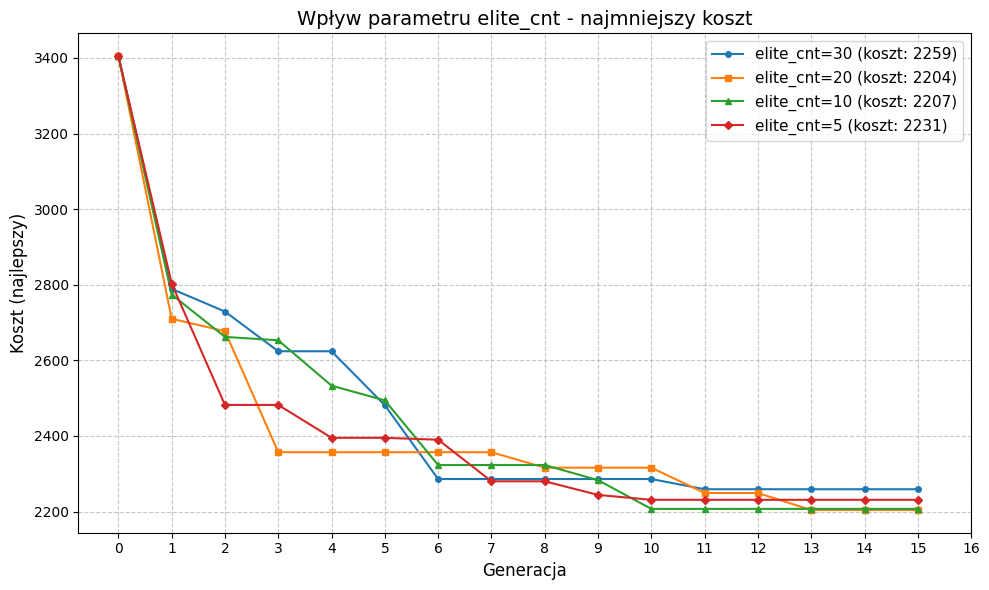

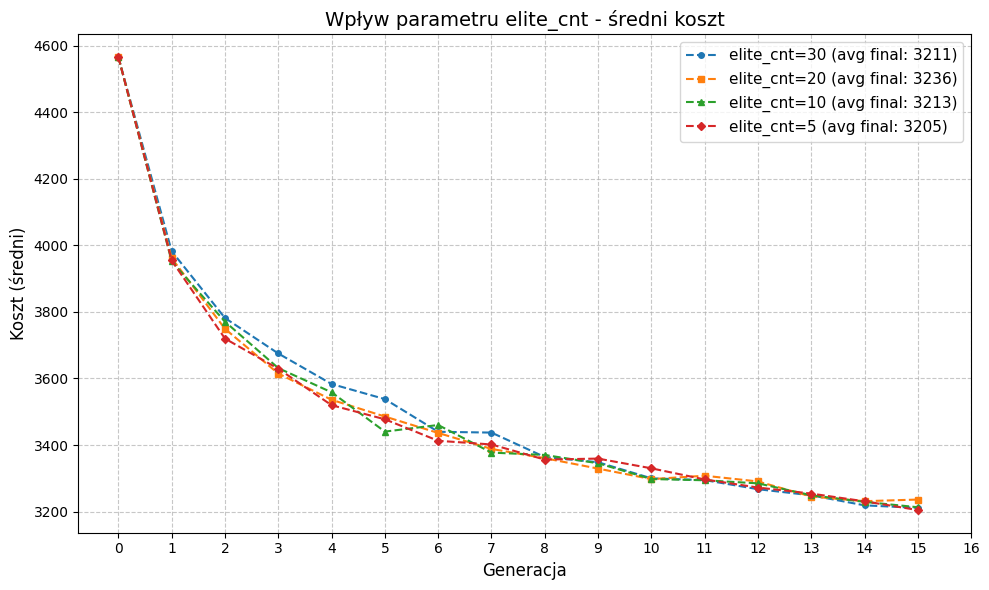


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
elite_cnt=30                   |    281.014 |       2259 |       True
elite_cnt=20                   |    294.451 |       2204 |       True
elite_cnt=10                   |    277.128 |       2207 |       True
elite_cnt=5                    |    289.197 |       2231 |       True


In [10]:
elite_cnt_exp = Experiment(ExperimentConfig(
    name="Wpływ parametru elite_cnt",
    seed=42,
    generations=15,
    population_size=50,
    no_simulations=10,
    adapters=[
        BeeAdapter(name="elite_cnt=30", good_elite_cnt=35, elite_cnt=30, local_elite_cnt=5, local_good_cnt=5),
        BeeAdapter(name="elite_cnt=20", good_elite_cnt=35,  elite_cnt=20, local_elite_cnt=5,  local_good_cnt=5),
        BeeAdapter(name="elite_cnt=10", good_elite_cnt=35,  elite_cnt=10, local_elite_cnt=5, local_good_cnt=5),
        BeeAdapter(name="elite_cnt=5", good_elite_cnt=35, elite_cnt=5, local_elite_cnt=5, local_good_cnt=5),
    ],
))

elite_cnt_exp.run()
elite_cnt_exp.plot_best_costs()
elite_cnt_exp.plot_avg_costs()
elite_cnt_exp.summary_table()

## Wpływ `local_elite_cnt`
Parametr ten reguluje ile sąsiednich rozwiązań przeszukamy w obrębie każdego z *elitarnych* rozwiązań

=== Wpływ parametru local_elite_cnt ===
Populacja początkowa: 50 osobników
Generacje: 15

Uruchamiam: local_elite_cnt=15...
local_elite_cnt=15:
  Czas:      579.252 s
  Koszt:     2152
  Poprawny:  True

Uruchamiam: local_elite_cnt=7...
local_elite_cnt=7:
  Czas:      364.409 s
  Koszt:     2188
  Poprawny:  True

Uruchamiam: local_elite_cnt=3...
local_elite_cnt=3:
  Czas:      214.485 s
  Koszt:     2179
  Poprawny:  True

Uruchamiam: local_elite_cnt=1...
local_elite_cnt=1:
  Czas:      150.110 s
  Koszt:     2387
  Poprawny:  True



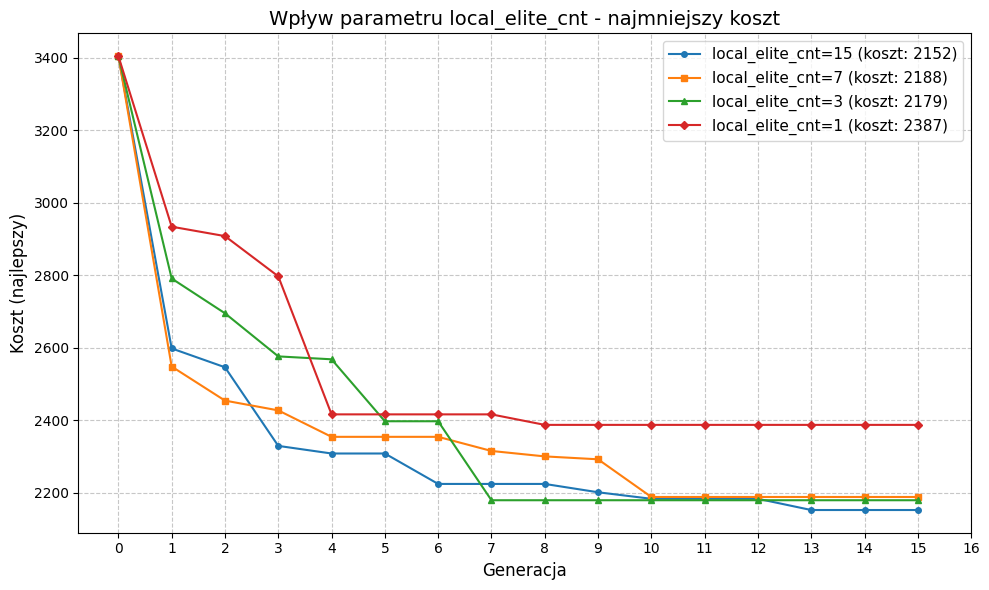

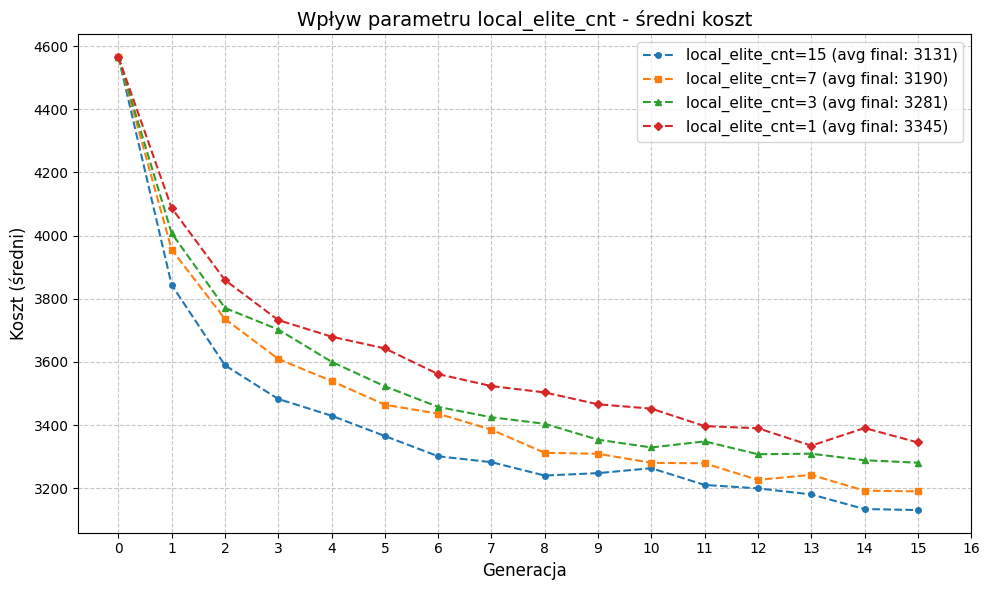


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
local_elite_cnt=15             |    579.252 |       2152 |       True
local_elite_cnt=7              |    364.409 |       2188 |       True
local_elite_cnt=3              |    214.485 |       2179 |       True
local_elite_cnt=1              |    150.110 |       2387 |       True


In [11]:
local_elite_cnt_exp = Experiment(ExperimentConfig(
    name="Wpływ parametru local_elite_cnt",
    seed=42,
    generations=15,
    population_size=50,
    no_simulations=10,
    adapters=[
        BeeAdapter(name="local_elite_cnt=15", good_elite_cnt=35, elite_cnt=20, local_elite_cnt=15, local_good_cnt=5),
        BeeAdapter(name="local_elite_cnt=7", good_elite_cnt=35,  elite_cnt=20, local_elite_cnt=7,  local_good_cnt=5),
        BeeAdapter(name="local_elite_cnt=3", good_elite_cnt=35,  elite_cnt=20, local_elite_cnt=3, local_good_cnt=5),
        BeeAdapter(name="local_elite_cnt=1", good_elite_cnt=35, elite_cnt=20, local_elite_cnt=1, local_good_cnt=5),
    ],
))

local_elite_cnt_exp.run()
local_elite_cnt_exp.plot_best_costs()
local_elite_cnt_exp.plot_avg_costs()
local_elite_cnt_exp.summary_table()

## Wpływ `local_good_cnt`
Parametr ten reguluje ile sąsiednich rozwiązań przeszukamy w obrębie każdego z *dobrych* rozwiązań

=== Wpływ parametru local_good_cnt ===
Populacja początkowa: 50 osobników
Generacje: 15

Uruchamiam: local_good_cnt=15...
local_good_cnt=15:
  Czas:      456.761 s
  Koszt:     2169
  Poprawny:  True

Uruchamiam: local_good_cnt=7...
local_good_cnt=7:
  Czas:      288.372 s
  Koszt:     2172
  Poprawny:  True

Uruchamiam: local_good_cnt=3...
local_good_cnt=3:
  Czas:      220.163 s
  Koszt:     2221
  Poprawny:  True

Uruchamiam: local_good_cnt=1...
local_good_cnt=1:
  Czas:      175.568 s
  Koszt:     2231
  Poprawny:  True



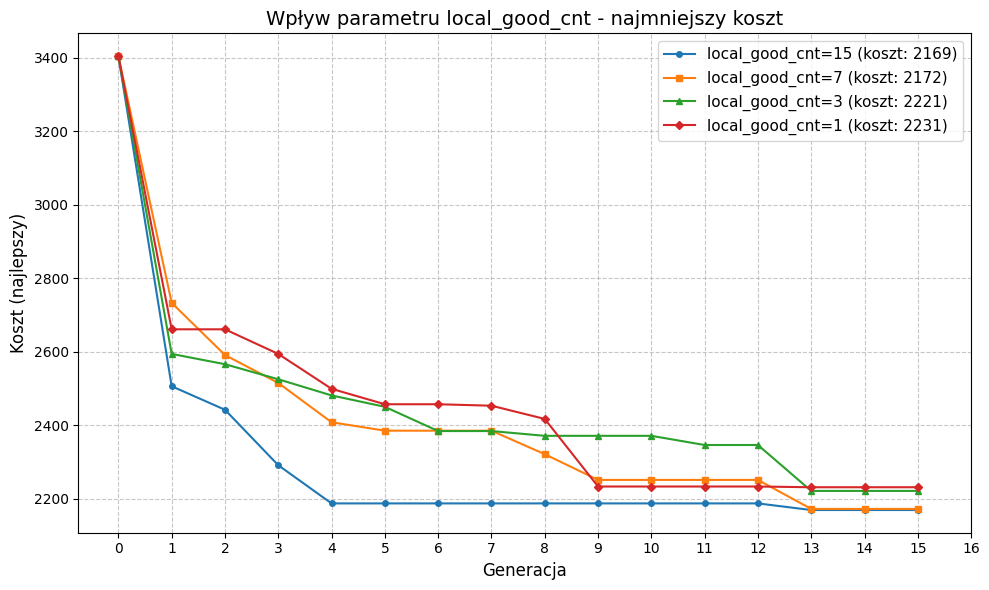

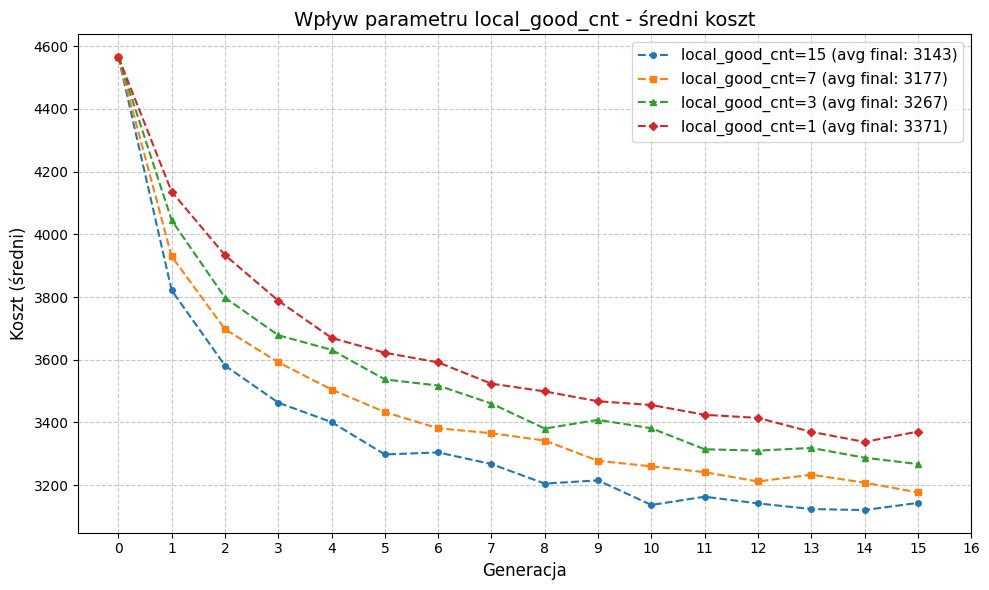


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
local_good_cnt=15              |    456.761 |       2169 |       True
local_good_cnt=7               |    288.372 |       2172 |       True
local_good_cnt=3               |    220.163 |       2221 |       True
local_good_cnt=1               |    175.568 |       2231 |       True


In [12]:
local_good_cnt_exp = Experiment(ExperimentConfig(
    name="Wpływ parametru local_good_cnt",
    seed=42,
    generations=15,
    population_size=50,
    no_simulations=10,
    adapters=[
        BeeAdapter(name="local_good_cnt=15", good_elite_cnt=35, elite_cnt=20, local_elite_cnt=5, local_good_cnt=15),
        BeeAdapter(name="local_good_cnt=7", good_elite_cnt=35,  elite_cnt=20, local_elite_cnt=5,  local_good_cnt=7),
        BeeAdapter(name="local_good_cnt=3", good_elite_cnt=35,  elite_cnt=20, local_elite_cnt=5, local_good_cnt=3),
        BeeAdapter(name="local_good_cnt=1", good_elite_cnt=35, elite_cnt=20, local_elite_cnt=5, local_good_cnt=1),
    ],
))

local_good_cnt_exp.run()
local_good_cnt_exp.plot_best_costs()
local_good_cnt_exp.plot_avg_costs()
local_good_cnt_exp.summary_table()

## Porównanie różnych podejść


=== Strategie pszczele ===
Populacja początkowa: 50 osobników
Generacje: 40

Uruchamiam: Genetyczny (dla porównania)...
Genetyczny (dla porównania):
  Czas:      138.922 s
  Koszt:     2058
  Poprawny:  True

Uruchamiam: Pszczeli zbalansowany...
Pszczeli zbalansowany:
  Czas:      266.714 s
  Koszt:     2110
  Poprawny:  True

Uruchamiam: Pszczeli dużo losowości...
Pszczeli dużo losowości:
  Czas:      147.032 s
  Koszt:     2361
  Poprawny:  True

Uruchamiam: Pszczeli silna elita...
Pszczeli silna elita:
  Czas:      436.025 s
  Koszt:     2131
  Poprawny:  True

Uruchamiam: Pszczeli rój...
Pszczeli rój:
  Czas:      548.134 s
  Koszt:     2074
  Poprawny:  True



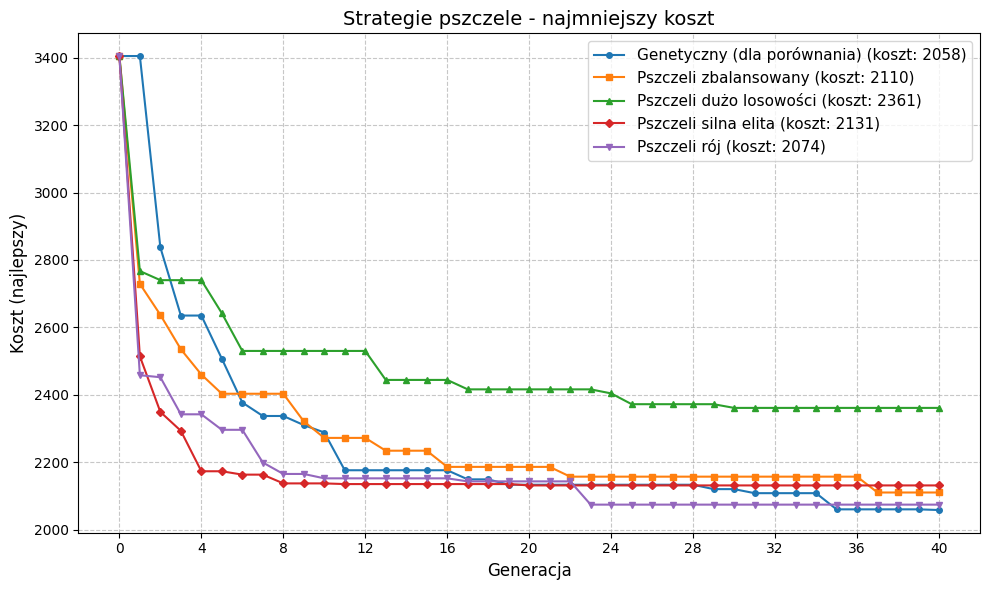


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
Genetyczny (dla porównania)    |    138.922 |       2058 |       True
Pszczeli zbalansowany          |    266.714 |       2110 |       True
Pszczeli dużo losowości        |    147.032 |       2361 |       True
Pszczeli silna elita           |    436.025 |       2131 |       True
Pszczeli rój                   |    548.134 |       2074 |       True


In [12]:
exp6 = Experiment(ExperimentConfig(
    name="Strategie pszczele",
    seed=42,
    generations=40,
    population_size=50,
    adapters=[
        GeneticAdapter(name="Genetyczny (dla porównania)", mutation_rate=0.25),
        BeeAdapter(name="Pszczeli zbalansowany",   good_elite_cnt=10, elite_cnt=3, local_elite_cnt=10, local_good_cnt=4),
        BeeAdapter(name="Pszczeli dużo losowości", good_elite_cnt=5,  elite_cnt=2, local_elite_cnt=2,  local_good_cnt=1),
        BeeAdapter(name="Pszczeli silna elita",    good_elite_cnt=3,  elite_cnt=3, local_elite_cnt=40, local_good_cnt=0),
        BeeAdapter(name="Pszczeli rój",            good_elite_cnt=15, elite_cnt=5, local_elite_cnt=20, local_good_cnt=8),
    ],
))

exp6.run()
exp6.plot_best_costs()
exp6.summary_table()

# Porównanie obu algorytmów

=== Porównanie dwóch algorytmów ===
Populacja początkowa: 50 osobników
Generacje: 40

Uruchamiam: Genetyczny (mr=1)...
Genetyczny (mr=1):
  Czas:      190.347 s
  Koszt:     2108
  Poprawny:  True

Uruchamiam: Genetyczny (mr=0.1)...
Genetyczny (mr=0.1):
  Czas:      180.134 s
  Koszt:     2128
  Poprawny:  True

Uruchamiam: Pszczeli (dużo istotnych)...
Pszczeli (dużo istotnych):
  Czas:      787.680 s
  Koszt:     2082
  Poprawny:  True

Uruchamiam: Pszczeli (dużo przeszukań)...
Pszczeli (dużo przeszukań):
  Czas:      668.454 s
  Koszt:     2060
  Poprawny:  True



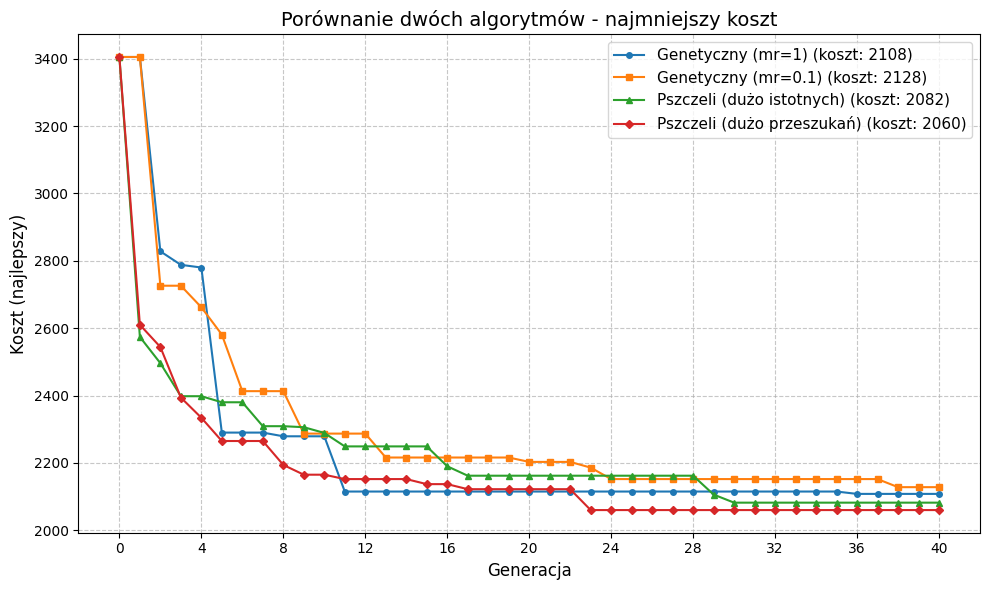

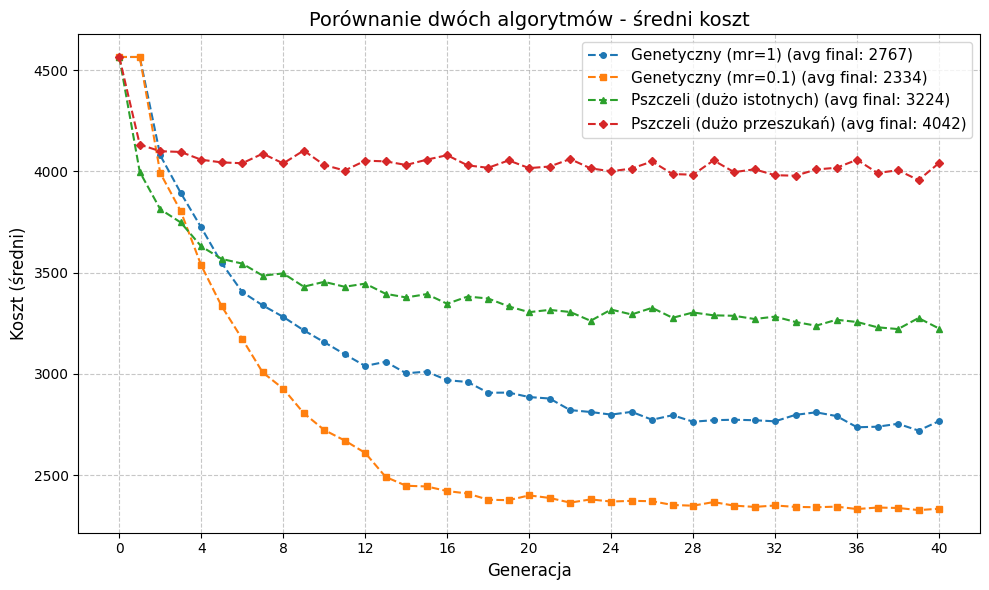


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
Genetyczny (mr=1)              |    190.347 |       2108 |       True
Genetyczny (mr=0.1)            |    180.134 |       2128 |       True
Pszczeli (dużo istotnych)      |    787.680 |       2082 |       True
Pszczeli (dużo przeszukań)     |    668.454 |       2060 |       True


In [13]:
mixed = Experiment(ExperimentConfig(
    name="Porównanie dwóch algorytmów",
    seed=42,
    generations=40,
    population_size=50,
    adapters=[
        GeneticAdapter(name="Genetyczny (mr=1)", mutation_rate=1),
        GeneticAdapter(name="Genetyczny (mr=0.1)", mutation_rate=0.1),
        BeeAdapter(name="Pszczeli (dużo istotnych)",   good_elite_cnt=30, elite_cnt=10, local_elite_cnt=10, local_good_cnt=5),
        BeeAdapter(name="Pszczeli (dużo przeszukań)",   good_elite_cnt=10, elite_cnt=5, local_elite_cnt=15, local_good_cnt=15),
    ],
))

mixed.run()
mixed.plot_best_costs()
mixed.plot_avg_costs()
mixed.summary_table()